# A neural network from scratch (numpy)

One hidden layer, 2 inputs -> hidden -> 1 output, trained with mini-batch gradient descent.
Plain numpy: forward pass, backward pass, update. Every activation and every loss is a
`(function, derivative)` pair in a dictionary and the backward pass is the general chain rule,
so any combination trains with no other code change.

On top of that core, this notebook shows the four things that separate a toy network from a
real one:

| | what it adds | where it shows up |
|---|---|---|
| **Dropout** | drops hidden units at random while training | section 3, 7 |
| **BatchNorm** | normalizes each hidden unit over the batch | section 3, 7 |
| **Train vs inference mode** | both layers above behave *differently* once training stops | section 6 |
| **Initialization** | including one that fails completely | section 4 |

The data is deliberately small and noisy, so the network **overfits** and the regularizers have
something to fix.

**Runtime.** A full rerun is about **8 minutes** on a laptop CPU, almost all of it in the four
cells that train several networks each. Treat the per-cell comments as typical, not exact: the
same notebook has taken 4 minutes and 26 minutes on this machine depending on what else was
running.

How to use it:

1. Change the names in `CONFIG` (section 5) and rerun from that cell down.
2. To add your own activation or loss: write the function and its derivative, add the pair to
   `ACTIVATIONS` or `LOSSES`, and run the **gradient check** (section 3) before training.

In [ ]:
# ~10 s: the first matplotlib / sklearn import is the slow part
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.datasets import make_moons


SEED = 509
RED, BLUE, ORANGE = "#D90012", "#0033A0", "#F2A800"  # Armenian flag colors
PROB_CMAP = LinearSegmentedColormap.from_list("blue_white_red", [BLUE, "white", RED])

## 1. Data, chosen so the network can overfit

Two moons again, but with two deliberate changes from the easy version: **`noise=0.35`** (the two
classes genuinely overlap, so some points are unlearnable) and a **60-point training set** against
540 test points.

That is the point. A 64-unit network has far more parameters than 60 training points, so it can
memorize them - including the mislabeled-looking ones - and we will watch it do exactly that.
With a clean, large training set there is no gap to see and nothing for dropout or BatchNorm to
repair.

train (60, 2) (60, 1), test (540, 2) (540, 1)


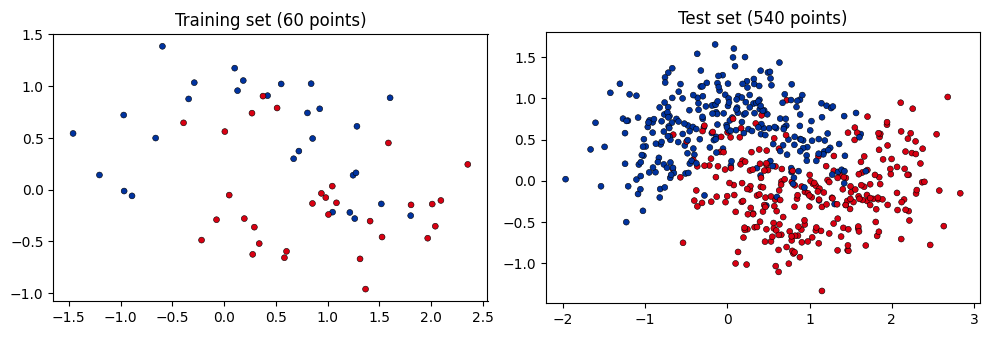

In [2]:
X, Y = make_moons(n_samples=600, noise=0.35, random_state=SEED)
Y = Y.reshape(-1, 1).astype(float)

X_train, Y_train = X[:60], Y[:60]      # small on purpose
X_test, Y_test = X[60:], Y[60:]
print(f"train {X_train.shape} {Y_train.shape}, test {X_test.shape} {Y_test.shape}")


def plot_data(X, Y, ax=None):
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=np.where(Y.ravel() == 1, RED, BLUE),
               edgecolors="k", linewidths=0.4, s=18)
    ax.set_aspect("equal")


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_data(X_train, Y_train, axes[0])
axes[0].set_title(f"Training set ({len(X_train)} points)")
plot_data(X_test, Y_test, axes[1])
axes[1].set_title(f"Test set ({len(X_test)} points)")
plt.tight_layout()
plt.show()

## 2. The swappable parts

### Activations

Each activation is a pair `(f, df)`. **Convention: `df` takes the pre-activation `z`**, the same
input as `f`. Mixing conventions is a classic bug: `s * (1 - s)` is the sigmoid derivative only
if you pass it the *output* `s = sigmoid(z)`.

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z) ** 2

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def leaky_relu(z, slope=0.01):
    return np.where(z > 0, z, slope * z)

def leaky_relu_derivative(z, slope=0.01):
    return np.where(z > 0, 1.0, slope)

def linear(z):
    return z

def linear_derivative(z):
    return np.ones_like(z)


ACTIVATIONS = {
    "sigmoid": (sigmoid, sigmoid_derivative),
    "tanh": (tanh, tanh_derivative),
    "relu": (relu, relu_derivative),
    "leaky_relu": (leaky_relu, leaky_relu_derivative),
    "linear": (linear, linear_derivative),
}

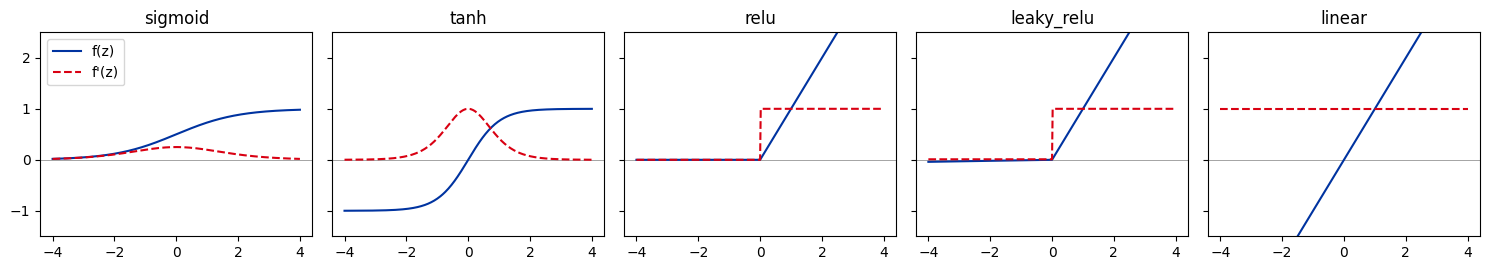

In [4]:
z = np.linspace(-4, 4, 401)
fig, axes = plt.subplots(1, len(ACTIVATIONS), figsize=(3 * len(ACTIVATIONS), 2.8), sharey=True)
for ax, (name, (f, df)) in zip(axes, ACTIVATIONS.items()):
    ax.axhline(0, color="gray", lw=0.5)
    ax.plot(z, f(z), color=BLUE, label="f(z)")
    ax.plot(z, df(z), color=RED, ls="--", label="f'(z)")
    ax.set_title(name)
    ax.set_ylim(-1.5, 2.5)
axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()

### Losses

A loss is also a pair `(L, dL)`. `L(Y, A)` returns one number; `dL(Y, A)` returns the gradient
with respect to the predictions `A`, same shape as `A`. Both **average over the batch**, so the
`1/N` lives here and nowhere else (the backward pass does not divide by `N` again).

Binary cross-entropy takes logs of `A` and `1 - A`, so it only makes sense when the output
activation is a sigmoid. `compatible()` enforces that instead of letting `np.clip` hide it.

In [ ]:
EPS = 1e-12

def mse(Y, A):
    return np.mean((A - Y) ** 2)

def mse_derivative(Y, A):
    return 2 * (A - Y) / Y.size

def bce(Y, A): # binary crosee ent
    A = np.clip(A, EPS, 1 - EPS) # so we don't have numeric problem when log(A)
    return -np.mean(Y * np.log(A) + (1 - Y) * np.log(1 - A))

def bce_derivative(Y, A):
    A = np.clip(A, EPS, 1 - EPS)
    return (A - Y) / (A * (1 - A) * Y.size)


LOSSES = {"mse": (mse, mse_derivative), "bce": (bce, bce_derivative)}


def compatible(output_activation, loss):
    return loss != "bce" or output_activation == "sigmoid"

### Initialization

He (2015) and Xavier/Glorot (2010) both scale random normal weights by the layer's size, so the
signal neither explodes nor dies as it passes through. He is designed for ReLU, Xavier for tanh
and sigmoid.

`zeros` is here **to fail**. Section 4 runs it.

In [6]:
def he_init(fan_in, fan_out, rng):
    return rng.normal(size=(fan_in, fan_out)) * np.sqrt(2 / fan_in)

def xavier_init(fan_in, fan_out, rng):
    return rng.normal(size=(fan_in, fan_out)) * np.sqrt(2 / (fan_in + fan_out))

def zeros_init(fan_in, fan_out, rng):
    return np.zeros((fan_in, fan_out))     # section 4 shows why this is a disaster


INITS = {"he": he_init, "xavier": xavier_init, "zeros": zeros_init}

## 3. The network

Shapes, with `N` samples and `H` hidden units: `X` is `(N, 2)`, `W1` is `(2, H)`, `W2` is `(H, 1)`.
Rows are samples, so a layer is `Z = X @ W + b`.

The forward pass is now four steps instead of two:

```
Z1 = X @ W1 + b1          ->   BatchNorm   ->   activation   ->   Dropout   ->   Z2 = A1 @ W2 + b2
```

**Two kinds of numbers live in the network.** `params` are learned by gradient descent
(`W1, b1, W2, b2`, plus `gamma, beta` when BatchNorm is on). `state` holds BatchNorm's running
mean and variance, which are *not* learned - they are averages recorded during training and
replayed at inference.

**BatchNorm** standardizes each hidden unit across the batch, then lets the network undo it if it
wants:

$$\hat z = \frac{z - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \qquad z_{\text{out}} = \gamma \hat z + \beta$$

**Dropout** (inverted dropout) zeroes each hidden unit with probability `p` and divides the
survivors by `1 - p`, so the *average* signal keeps the same size and inference needs no
correction at all.

**The `training` flag is not cosmetic**, and it is the one thing people get wrong:

| | `training=True` | `training=False` (inference) |
|---|---|---|
| BatchNorm | uses **this batch's** mean/var, and updates the running averages | uses the **running** averages |
| Dropout | drops units at random | does nothing |

Forget it and you evaluate a model that is still randomly deleting a third of its own neurons.

In [7]:
BN_EPS = 1e-5        # keeps the division safe if a unit is constant across the batch
BN_MOMENTUM = 0.9    # running_avg = 0.9 * running_avg + 0.1 * this_batch


def initialize(input_size, hidden_size, output_size, cfg):
    rng = np.random.default_rng(cfg["seed"])
    init_fn = INITS[cfg["init"]]
    params = {
        "W1": init_fn(input_size, hidden_size, rng),
        "b1": np.zeros((1, hidden_size)),
        "W2": init_fn(hidden_size, output_size, rng),
        "b2": np.zeros((1, output_size)),
    }
    if cfg["batchnorm"]:
        params["gamma"] = np.ones((1, hidden_size))    # scale, learned
        params["beta"] = np.zeros((1, hidden_size))    # shift, learned
    # not learned: recorded while training, used at inference
    state = {"running_mean": np.zeros((1, hidden_size)),
             "running_var": np.ones((1, hidden_size))}
    return params, state

In [8]:
def forward(X, params, state, cfg, training, rng=None):
    f1, _ = ACTIVATIONS[cfg["hidden_activation"]]
    f2, _ = ACTIVATIONS[cfg["output_activation"]]

    Z1 = X @ params["W1"] + params["b1"]

    if cfg["batchnorm"]:
        if training:
            mean = Z1.mean(axis=0, keepdims=True)      # statistics of THIS batch
            var = Z1.var(axis=0, keepdims=True)
            state["running_mean"] = BN_MOMENTUM * state["running_mean"] + (1 - BN_MOMENTUM) * mean
            state["running_var"] = BN_MOMENTUM * state["running_var"] + (1 - BN_MOMENTUM) * var
        else:
            mean, var = state["running_mean"], state["running_var"]   # replayed, not recomputed
        std = np.sqrt(var + BN_EPS)
        Z1_hat = (Z1 - mean) / std
        Z1_out = params["gamma"] * Z1_hat + params["beta"]
    else:
        std = Z1_hat = None
        Z1_out = Z1

    A1 = f1(Z1_out)

    if training and cfg["dropout"] > 0:
        keep = 1 - cfg["dropout"]
        survives = rng.random(A1.shape) < keep         # True for the units we keep
        mask = survives / keep                         # inverted dropout: scale survivors up
        A1 = A1 * mask
    else:
        mask = None                                     # inference: the layer disappears

    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = f2(Z2)
    cache = {"X": X, "Z1_hat": Z1_hat, "std": std, "Z1_out": Z1_out,
             "A1": A1, "mask": mask, "Z2": Z2, "A2": A2}
    return A2, cache

`backward` is the chain rule, one step at a time, and it never assumes which activation or loss is
used. Each new layer adds exactly one line going backwards:

$$
\frac{\partial L}{\partial Z_2} = \frac{\partial L}{\partial A_2} \odot f_2'(Z_2), \qquad
\frac{\partial L}{\partial A_1} = \frac{\partial L}{\partial Z_2} W_2^\top
$$

Dropout's backward is the same mask again - a unit that was dropped forward gets no gradient back.
BatchNorm's is the one formula here worth reading twice: because $\mu_B$ and $\sigma_B$ depend on
**every sample in the batch**, changing one sample's $z$ changes every other sample's output, and
those paths all contribute:

$$
\frac{\partial L}{\partial z_i} = \frac{1}{N\sigma_B}\left( N \frac{\partial L}{\partial \hat z_i}
- \sum_j \frac{\partial L}{\partial \hat z_j}
- \hat z_i \sum_j \frac{\partial L}{\partial \hat z_j} \hat z_j \right)
$$

You do not have to trust it. The gradient check below tests it against finite differences.

In [9]:
def backward(Y, params, cache, cfg):
    _, df1 = ACTIVATIONS[cfg["hidden_activation"]]
    _, df2 = ACTIVATIONS[cfg["output_activation"]]
    _, dL = LOSSES[cfg["loss"]]

    dZ2 = dL(Y, cache["A2"]) * df2(cache["Z2"])          # through the output activation
    grads = {"W2": cache["A1"].T @ dZ2,
             "b2": dZ2.sum(axis=0, keepdims=True)}

    dA1 = dZ2 @ params["W2"].T                            # send the error back through W2
    if cache["mask"] is not None:
        dA1 = dA1 * cache["mask"]                         # dropped units get no gradient
    dZ1_out = dA1 * df1(cache["Z1_out"])                  # through the hidden activation

    if cfg["batchnorm"]:
        grads["gamma"] = (dZ1_out * cache["Z1_hat"]).sum(axis=0, keepdims=True)
        grads["beta"] = dZ1_out.sum(axis=0, keepdims=True)
        dZ1_hat = dZ1_out * params["gamma"]
        N = cache["X"].shape[0]
        dZ1 = (N * dZ1_hat
               - dZ1_hat.sum(axis=0, keepdims=True)
               - cache["Z1_hat"] * (dZ1_hat * cache["Z1_hat"]).sum(axis=0, keepdims=True)
               ) / (N * cache["std"])
    else:
        dZ1 = dZ1_out

    grads["W1"] = cache["X"].T @ dZ1
    grads["b1"] = dZ1.sum(axis=0, keepdims=True)
    return grads


def update_params(params, grads, learning_rate):
    for key in params:
        params[key] -= learning_rate * grads[key]
    return params


def check_config(cfg):
    for key, table in [("hidden_activation", ACTIVATIONS), ("output_activation", ACTIVATIONS),
                       ("loss", LOSSES), ("init", INITS)]:
        if cfg[key] not in table:
            raise ValueError(f"{key}={cfg[key]!r} is not one of {list(table)}")
    if not compatible(cfg["output_activation"], cfg["loss"]):
        raise ValueError(f"loss='bce' needs predictions in (0, 1): use output_activation='sigmoid', "
                         f"not {cfg['output_activation']!r}")
    if not 0 <= cfg["dropout"] < 1:
        raise ValueError(f"dropout must be in [0, 1), got {cfg['dropout']}")

### Gradient check

The one test that catches a wrong derivative. Nudge each parameter by $\pm h$, measure how the loss
changes, and compare with what `backward` computed:

$$\frac{\partial L}{\partial w} \approx \frac{L(w + h) - L(w - h)}{2h}$$

A wrong derivative does **not** raise an error - training still runs, it just learns badly. So this
cell raises instead, and it now sweeps **BatchNorm on/off and dropout on/off** as well as every
activation and loss pair.

One detail that matters with dropout: the mask is random, so `L(w + h)` and `L(w - h)` would use
*different* networks and the comparison would be meaningless. Passing a **freshly seeded generator
into every forward call** makes the mask identical each time, which is what makes dropout
checkable at all.

In [10]:
# ~3 s: 120 configurations, each one finite-differenced
def numeric_gradients(X, Y, params, state, cfg, h=1e-6):
    # Finite differences, in training mode, with the dropout mask held fixed.
    loss_fn, _ = LOSSES[cfg["loss"]]

    def loss_at(current_params):
        # a fresh generator => the same dropout mask every call; dict(state) => running stats
        # are not polluted by the probing
        A2, _ = forward(X, current_params, dict(state), cfg, True, np.random.default_rng(SEED))
        return loss_fn(Y, A2)

    grads = {}
    for key, P in params.items():
        g = np.zeros_like(P)
        for idx in np.ndindex(P.shape):
            original = P[idx]
            P[idx] = original + h
            loss_plus = loss_at(params)
            P[idx] = original - h
            loss_minus = loss_at(params)
            P[idx] = original
            g[idx] = (loss_plus - loss_minus) / (2 * h)
        grads[key] = g
    return grads


def gradient_check(n_samples=20, hidden_size=4):
    X_small, Y_small = X_train[:n_samples], Y_train[:n_samples]
    rng = np.random.default_rng(SEED)
    failures, worst, n_checked = [], 0.0, 0

    for batchnorm in (False, True):
        for dropout in (0.0, 0.3):
            for hidden in ACTIVATIONS:
                for output in ACTIVATIONS:
                    for loss in LOSSES:
                        if not compatible(output, loss):
                            continue
                        cfg = {"hidden_activation": hidden, "output_activation": output,
                               "loss": loss, "init": "he", "seed": SEED,
                               "batchnorm": batchnorm, "dropout": dropout}
                        params, state = initialize(2, hidden_size, 1, cfg)
                        # Random biases, not zeros: with zero biases a sample whose hidden ReLUs
                        # are all off sits exactly on ReLU's kink, where the finite difference
                        # (slope 0.5) disagrees with the formula (slope 0).
                        params["b1"] = rng.normal(scale=0.1, size=params["b1"].shape)
                        params["b2"] = rng.normal(scale=0.1, size=params["b2"].shape)

                        _, cache = forward(X_small, params, dict(state), cfg, True,
                                           np.random.default_rng(SEED))
                        analytic = backward(Y_small, params, cache, cfg)
                        numeric = numeric_gradients(X_small, Y_small, params, state, cfg)
                        for key in params:
                            worst = max(worst, np.abs(analytic[key] - numeric[key]).max())
                            if not np.allclose(analytic[key], numeric[key], rtol=1e-4, atol=1e-7):
                                failures.append(f"bn={batchnorm} dropout={dropout} "
                                                f"{hidden} -> {output}, {loss}: d{key}")
                        n_checked += 1

    if failures:
        raise AssertionError("gradient check failed for:\n  " + "\n  ".join(failures))
    print(f"gradient check passed for {n_checked} configurations "
          f"(largest |analytic - numeric| = {worst:.1e})")


gradient_check()

gradient check passed for 120 configurations (largest |analytic - numeric| = 6.2e-10)


## 4. Two things to check before you train anything

### The loss at initialization

**Predict first.** Before a single gradient step, what should the loss be?

A freshly initialized network knows nothing, so it should sit near $p = 0.5$ for every point, and
binary cross-entropy at $p = 0.5$ is

$$-\log(0.5) = \log 2 \approx 0.693$$

This is the cheapest bug detector in deep learning. If your first loss is not near $\log 2$ for
2 classes (or $\log C$ for $C$ classes - lecture [45] does the $\log 10 \approx 2.30$ version),
something is already wrong: the labels are shifted, the output layer has the wrong size, or the
initial weights are far too large.

In [11]:
CHECK_CFG = {"hidden_size": 64, "hidden_activation": "relu", "output_activation": "sigmoid",
             "loss": "bce", "init": "he", "seed": SEED, "batchnorm": False, "dropout": 0.0}
params, state = initialize(2, CHECK_CFG["hidden_size"], 1, CHECK_CFG)
A2, _ = forward(X_train, params, state, CHECK_CFG, training=False)

print(f"mean prediction at init : {A2.mean():.4f}   (expected about 0.5)")
print(f"loss at init            : {bce(Y_train, A2):.4f}")
print(f"log 2                   : {np.log(2):.4f}")

mean prediction at init : 0.4407   (expected about 0.5)
loss at init            : 0.6869
log 2                   : 0.6931


It is close to $\log 2$ but not exactly: He initialization gives small non-zero weights, so the
logits are not exactly 0 and the predictions are scattered around 0.5 rather than sitting on it.
"Near $\log 2$" is the check - an exact match would actually mean every logit is exactly zero.

### Predict first: what happens if we initialize everything to zero?

Zero is the most natural-looking starting point in the world. Before running the next cell, decide
what you think happens: does the network train slowly, train normally, or not train at all?

In [12]:
zero_cfg = {**CHECK_CFG, "init": "zeros"}
params, state = initialize(2, 8, 1, zero_cfg)
A2, cache = forward(X_train, params, state, zero_cfg, training=True, rng=np.random.default_rng(SEED))
grads = backward(Y_train, params, cache, zero_cfg)

print("gradients at the very first step, with everything initialized to zero:")
for key in ["W1", "b1", "W2", "b2"]:
    print(f"  max |d{key}| = {np.abs(grads[key]).max():.3e}")

gradients at the very first step, with everything initialized to zero:
  max |dW1| = 0.000e+00
  max |db1| = 0.000e+00
  max |dW2| = 0.000e+00
  max |db2| = 1.667e-02


**Every weight gradient is exactly zero**, so gradient descent has nothing to move. Only `b2`, the
output bias, gets a signal.

The reason is a symmetry argument, and it is worth stating precisely because it is the whole
argument for random initialization:

1. `W2 = 0`, so the error that flows back to the hidden layer, $\partial L/\partial A_1 = \delta_2 W_2^\top$, is zero. `W1` can never change.
2. `A1 = f(0) = 0` for ReLU and tanh, so $\partial L/\partial W_2 = A_1^\top \delta_2$ is zero too. `W2` can never change either.
3. Even if you fixed one of those, all `H` hidden units would still compute the identical function
   forever, because they start identical and receive identical gradients. A layer of 64 clones has
   the capacity of one unit.

Random initialization is not a heuristic for speed. It is what **breaks the symmetry** between
units so they can specialize. The training run in section 7 confirms the consequence: the
all-zeros network never leaves $\log 2$.

## 5. The training loop

Two changes from the textbook version:

- **Mini-batches.** The data is shuffled each epoch and the network updates once per batch, not
  once per epoch. This is the SGD of lecture [44], and BatchNorm needs it - "the statistics of this
  batch" is only meaningful if there are batches.
- **Metrics are measured in inference mode.** Training runs with `training=True`; the loss we
  *record* is computed with `training=False`, because a loss measured through random dropout masks
  is not the model's loss, it is noise.

In [13]:
CONFIG = {
    "hidden_size": 64,
    "hidden_activation": "relu",     # any key of ACTIVATIONS
    "output_activation": "sigmoid",  # any key of ACTIVATIONS
    "loss": "bce",                   # any key of LOSSES ("bce" needs a sigmoid output)
    "init": "he",                    # any key of INITS
    "dropout": 0.0,                  # 0.0 = off; 0.3 means 30% of hidden units dropped
    "batchnorm": False,
    "learning_rate": 0.3,
    "batch_size": 16,
    "epochs": 4000,
    "seed": SEED,
}

In [23]:
rng = np.random.default_rng(509)

rng.permutation(5)

array([0, 3, 2, 1, 4])

In [ ]:
def evaluate_loss(X, Y, params, state, cfg):
    loss_fn, _ = LOSSES[cfg["loss"]]
    A2, _ = forward(X, params, state, cfg, training=False)     # inference mode
    return loss_fn(Y, A2)


def predict_proba(X, params, state, cfg):
    return forward(X, params, state, cfg, training=False)[0]


def accuracy(X, Y, params, state, cfg, threshold=0.5):
    probabilities = predict_proba(X, params, state, cfg)
    predicted_class = probabilities > threshold      # True/False, same shape as Y
    correct = predicted_class == Y
    return float(correct.mean())


def train(X, Y, cfg, X_val, Y_val, log_every=1000):
    check_config(cfg)
    params, state = initialize(X.shape[1], cfg["hidden_size"], Y.shape[1], cfg)
    rng = np.random.default_rng(cfg["seed"])
    history = {"train": [], "val": []}

    for epoch in range(cfg["epochs"]):
        order = rng.permutation(len(X))                        # reshuffle every epoch
        for start in range(0, len(X), cfg["batch_size"]):
            batch = order[start:start + cfg["batch_size"]]
            _, cache = forward(X[batch], params, state, cfg, training=True, rng=rng)
            grads = backward(Y[batch], params, cache, cfg)
            params = update_params(params, grads, cfg["learning_rate"])

        train_loss = evaluate_loss(X, Y, params, state, cfg)
        if not np.isfinite(train_loss):
            raise FloatingPointError(f"loss is {train_loss} at epoch {epoch}: "
                                     f"learning_rate={cfg['learning_rate']} is probably too high")
        history["train"].append(train_loss)
        history["val"].append(evaluate_loss(X_val, Y_val, params, state, cfg))

        if log_every and epoch % log_every == 0:
            print(f"epoch {epoch:5d}  train loss {train_loss:.4f}  "
                  f"val loss {history['val'][-1]:.4f}")

    return params, state, history

In [15]:
def plot_decision_boundary(params, state, cfg, X, Y, ax=None):
    ax = ax or plt.gca()

    # a 300x300 grid covering the data, a bit wider than the points themselves
    x_values = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300)
    y_values = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
    xx, yy = np.meshgrid(x_values, y_values)

    grid_points = np.column_stack([xx.ravel(), yy.ravel()])   # (90000, 2): one row per pixel
    probabilities = predict_proba(grid_points, params, state, cfg)
    P = probabilities.reshape(xx.shape)                       # back to the grid shape

    ax.contourf(xx, yy, P, levels=np.linspace(0, 1, 11), cmap=PROB_CMAP, alpha=0.45, extend="both")
    if P.min() < 0.5 < P.max():                               # only if the boundary is on screen
        ax.contour(xx, yy, P, levels=[0.5], colors="k", linewidths=1.5)
    plot_data(X, Y, ax)


def smooth(values, window):
    """Moving average: the average of each point and the `window - 1` points before it."""
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


def plot_history(history, cfg, ax=None):
    ax = ax or plt.gca()
    n_epochs = len(history["train"])

    # 60 training points reshuffled into new mini-batches every epoch makes the per-epoch
    # loss very jumpy. Draw the raw curve faintly and a moving average on top: the trend is
    # what you want to read, but hiding the noise entirely would be dishonest.
    window = max(5, n_epochs // 40)
    window = min(window, n_epochs)
    smoothed_epochs = np.arange(window - 1, n_epochs)   # a mean needs `window` epochs first

    ax.plot(history["train"], color=BLUE, lw=0.8, alpha=0.30)
    ax.plot(history["val"], color=RED, lw=0.8, alpha=0.30, ls="--")
    ax.plot(smoothed_epochs, smooth(history["train"], window), color=BLUE, lw=2,
            label=f"train ({window}-epoch mean)")
    ax.plot(smoothed_epochs, smooth(history["val"], window), color=RED, lw=2, ls="--",
            label=f"validation ({window}-epoch mean)")

    best = int(np.argmin(history["val"]))
    ax.axvline(best, color=ORANGE, lw=1.2)
    ax.annotate(f"best val\nepoch {best}", (best, min(history["val"])), fontsize=8,
                color="#7a5500", xytext=(8, 14), textcoords="offset points")

    ax.set_yscale("log")
    ax.set_xlabel("epoch")
    ax.set_ylabel(f"{cfg['loss']} loss (log scale)")
    ax.legend(fontsize=8)

### The overfitting run

No dropout, no BatchNorm, 64 hidden units, 60 training points. Watch the two curves separate.

epoch     0  train loss 0.6124  val loss 0.5936


epoch  1000  train loss 0.1946  val loss 0.7856


epoch  2000  train loss 0.1864  val loss 1.4561


epoch  3000  train loss 0.1460  val loss 1.5657



train accuracy 91.7%, test accuracy 77.6%
final train loss 0.134, final val loss 1.486
best val loss 0.325 at epoch 106


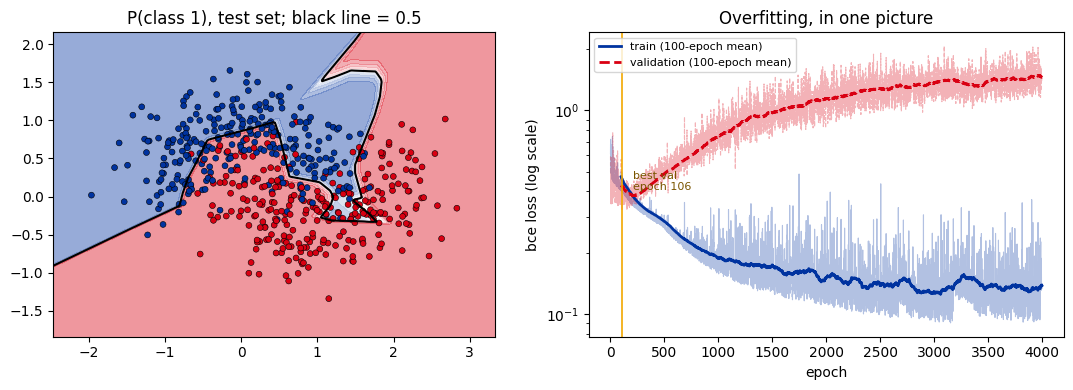

In [16]:
# ~30 s: one 4000-epoch run
params, state, history = train(X_train, Y_train, CONFIG, X_test, Y_test)

print(f"\ntrain accuracy {accuracy(X_train, Y_train, params, state, CONFIG):.1%}, "
      f"test accuracy {accuracy(X_test, Y_test, params, state, CONFIG):.1%}")
print(f"final train loss {history['train'][-1]:.3f}, final val loss {history['val'][-1]:.3f}")
print(f"best val loss {min(history['val']):.3f} at epoch {int(np.argmin(history['val']))}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_decision_boundary(params, state, CONFIG, X_test, Y_test, axes[0])
axes[0].set_title("P(class 1), test set; black line = 0.5")
plot_history(history, CONFIG, axes[1])
axes[1].set_title("Overfitting, in one picture")
plt.tight_layout()
plt.show()

**Read the curves.** The training loss keeps falling; the validation loss falls for about a hundred
epochs, bottoms out, and then climbs for the remaining few thousand - ending several times *worse*
than where it started improving. The orange line marks the minimum. (Each panel draws the raw per-epoch loss faintly and a moving average over it in bold - with 60 training points reshuffled every epoch the raw curve is genuinely that jumpy, and the bold line is the trend to read.) That is the model you actually
wanted, and everything after it is the network memorizing 60 points.

Two honest readings of the picture:

- **Early stopping is free.** Keeping the weights at the orange line costs one `if` statement in
  the loop and recovers most of the loss. It is exercise 2.
- **Look at the boundary, not just the number.** The shape wanders out to capture individual
  training points that happen to sit on the wrong side of the overlap. A boundary that contorts
  itself around single points is what memorization looks like geometrically.

## 6. Train mode vs inference mode, seen directly

This is the part that is invisible in a toy network and bites in a real one. Train a network **with
dropout**, then run the exact same inputs through it in both modes.

In [17]:
# ~5 s: trains a 300-epoch model first
demo_cfg = {**CONFIG, "dropout": 0.3, "batchnorm": True, "epochs": 300}
demo_params, demo_state, _ = train(X_train, Y_train, demo_cfg, X_test, Y_test, log_every=0)

rng = np.random.default_rng(SEED)
print("same 5 test points, forward pass repeated 3 times\n")
print("training=True  (dropout active, BatchNorm uses the batch):")
for _ in range(3):
    p = forward(X_test[:5], demo_params, dict(demo_state), demo_cfg, True, rng)[0]
    print("   ", np.round(p.ravel(), 3))

print("\ntraining=False (inference):")
for _ in range(3):
    p = forward(X_test[:5], demo_params, demo_state, demo_cfg, False)[0]
    print("   ", np.round(p.ravel(), 3))

loss_fn, _ = LOSSES[demo_cfg["loss"]]          # not hardcoded: follows CONFIG

# the training-mode loss is a different number every pass, so average a few of them
losses = []
for _ in range(20):
    predictions, _ = forward(X_test, demo_params, dict(demo_state), demo_cfg, True, rng)
    losses.append(loss_fn(Y_test, predictions))
train_mode_loss = np.mean(losses)
print(f"\ntest loss in training mode (avg of 20) : {train_mode_loss:.4f}")
print(f"test loss in inference mode            : {evaluate_loss(X_test, Y_test, demo_params, demo_state, demo_cfg):.4f}")

same 5 test points, forward pass repeated 3 times

training=True  (dropout active, BatchNorm uses the batch):
    [0.869 0.11  0.94  0.128 0.401]
    [0.803 0.166 0.942 0.039 0.33 ]
    [0.925 0.132 0.959 0.056 0.326]

training=False (inference):
    [0.838 0.066 0.868 0.139 0.304]
    [0.838 0.066 0.868 0.139 0.304]
    [0.838 0.066 0.868 0.139 0.304]



test loss in training mode (avg of 20) : 0.3892
test loss in inference mode            : 0.3143


In training mode the same input gives a **different answer every time**, because a different third
of the hidden units is switched off each pass and BatchNorm standardizes using whatever batch you
happened to send. In inference mode the network is deterministic and measurably better.

This is why PyTorch makes you write `model.train()` and `model.eval()`, and why forgetting
`model.eval()` is one of the most common bugs in student code: nothing crashes, the accuracy is
just quietly worse and irreproducible.

One more consequence worth knowing: **with BatchNorm, `b1` is dead weight.** BatchNorm subtracts
the batch mean, which removes any constant added before it, and `beta` puts a shift back in. The
gradient proves it:

In [18]:
bn_cfg = {**CONFIG, "batchnorm": True}
p, s = initialize(2, 8, 1, bn_cfg)
_, cache = forward(X_train, p, s, bn_cfg, training=True, rng=np.random.default_rng(SEED))
g = backward(Y_train, p, cache, bn_cfg)
print(f"max |dW1| = {np.abs(g['W1']).max():.3e}")
print(f"max |db1| = {np.abs(g['b1']).max():.3e}   <- zero: b1 cannot affect the loss")

max |dW1| = 1.755e+00
max |db1| = 6.210e-16   <- zero: b1 cannot affect the loss


That is exactly why the PyTorch version in section 9 writes `nn.Linear(2, 64, bias=False)` before a
`BatchNorm1d`. Keeping `b1` is harmless here, just useless.

## 7. The two regularizers, and the init that fails

Same network, same seed, same 4000 epochs. Only the listed setting changes.

plain                        train loss 0.134  val loss 1.486  (best 0.325)  test accuracy 77.6%


dropout=0.5                  train loss 0.206  val loss 0.653  (best 0.312)  test accuracy 78.1%


batchnorm=True               train loss 0.276  val loss 0.349  (best 0.276)  test accuracy 84.1%


batchnorm=True, dropout=0.3  train loss 0.338  val loss 0.354  (best 0.297)  test accuracy 84.3%


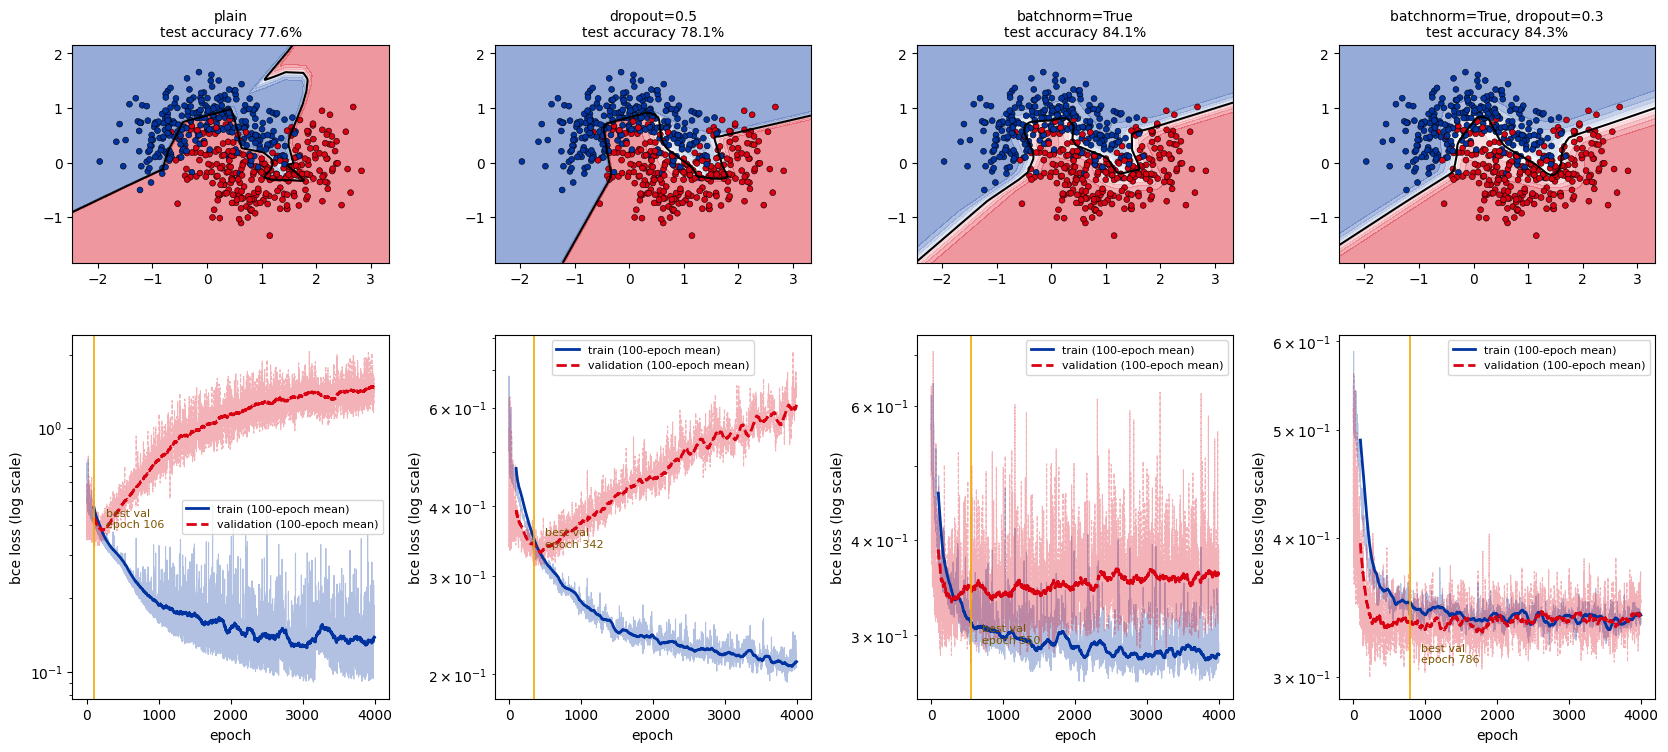

In [19]:
# ~1.5 min: four 4000-epoch runs
def compare(changes, base=CONFIG):
    fig, axes = plt.subplots(2, len(changes), figsize=(4.2 * len(changes), 8), squeeze=False)
    for col, change in enumerate(changes):
        cfg = {**base, **change}
        params, state, history = train(X_train, Y_train, cfg, X_test, Y_test, log_every=0)
        # "dropout=0.5", or "plain" when nothing was changed
        label = ", ".join(f"{key}={value}" for key, value in change.items()) or "plain"
        test_acc = accuracy(X_test, Y_test, params, state, cfg)
        final_train = history["train"][-1]
        final_val = history["val"][-1]
        best_val = min(history["val"])
        print(f"{label:<28} train loss {final_train:.3f}  val loss {final_val:.3f}"
              f"  (best {best_val:.3f})  test accuracy {test_acc:.1%}")
        plot_decision_boundary(params, state, cfg, X_test, Y_test, axes[0, col])
        axes[0, col].set_title(f"{label}\ntest accuracy {test_acc:.1%}", fontsize=10)
        plot_history(history, cfg, axes[1, col])
    plt.tight_layout()
    plt.show()


compare([{}, {"dropout": 0.5}, {"batchnorm": True}, {"batchnorm": True, "dropout": 0.3}])

**What happened.** Both regularizers do their job, and they do it differently:

- **Dropout** cuts the final validation loss to less than half of the plain run. The training loss
  goes *up* - which is the point. A network that cannot rely on any particular unit being present
  has to spread the job across many of them, and spread-out solutions generalize better.
- **BatchNorm** helps most here, on both loss and accuracy. Note it is not primarily a regularizer:
  its job is to keep each hidden unit's inputs in a sane range so gradients stay healthy. The
  regularizing side effect comes from the batch statistics being slightly different every batch,
  which is a small dose of noise on every forward pass.
- The **validation curves change shape**, not just height: the plain run's U turns sharply upward,
  the regularized ones stay much flatter for thousands of epochs. Flat means *less sensitive to when
  you stop*, which is worth as much in practice as the loss number.

Now the zero initialization, with everything else held fixed:

plain                        train loss 0.134  val loss 1.486  (best 0.325)  test accuracy 77.6%


init=zeros                   train loss 0.693  val loss 0.694  (best 0.693)  test accuracy 49.8%


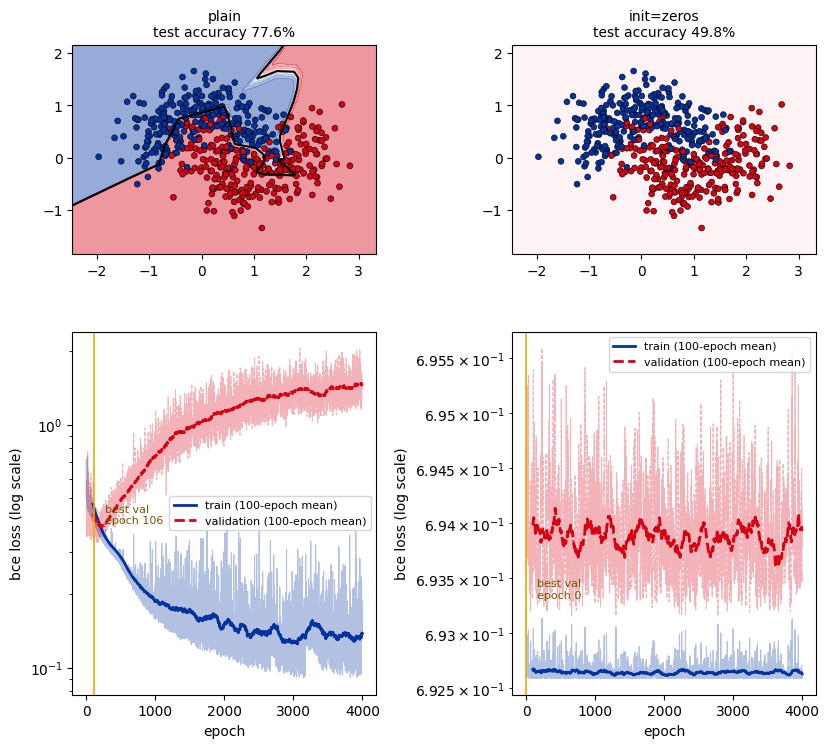

In [20]:
# ~40 s: two 4000-epoch runs
compare([{}, {"init": "zeros"}])

The all-zeros network sits at $\log 2 \approx 0.693$ for all 4000 epochs and predicts one class for
the entire plane - exactly what section 4's gradient argument predicted. Its accuracy is whatever
the majority class happens to be, which is chance.

## 8. Swapping the hidden activation

The parts are interchangeable, so this is one line. With the noisy 60-point training set, the
result is more interesting than on easy data.

hidden_activation=linear     train loss 0.516  val loss 0.397  (best 0.332)  test accuracy 83.5%


hidden_activation=sigmoid    train loss 0.227  val loss 0.787  (best 0.361)  test accuracy 79.1%


hidden_activation=tanh       train loss 0.092  val loss 1.057  (best 0.308)  test accuracy 75.9%


hidden_activation=relu       train loss 0.134  val loss 1.486  (best 0.325)  test accuracy 77.6%


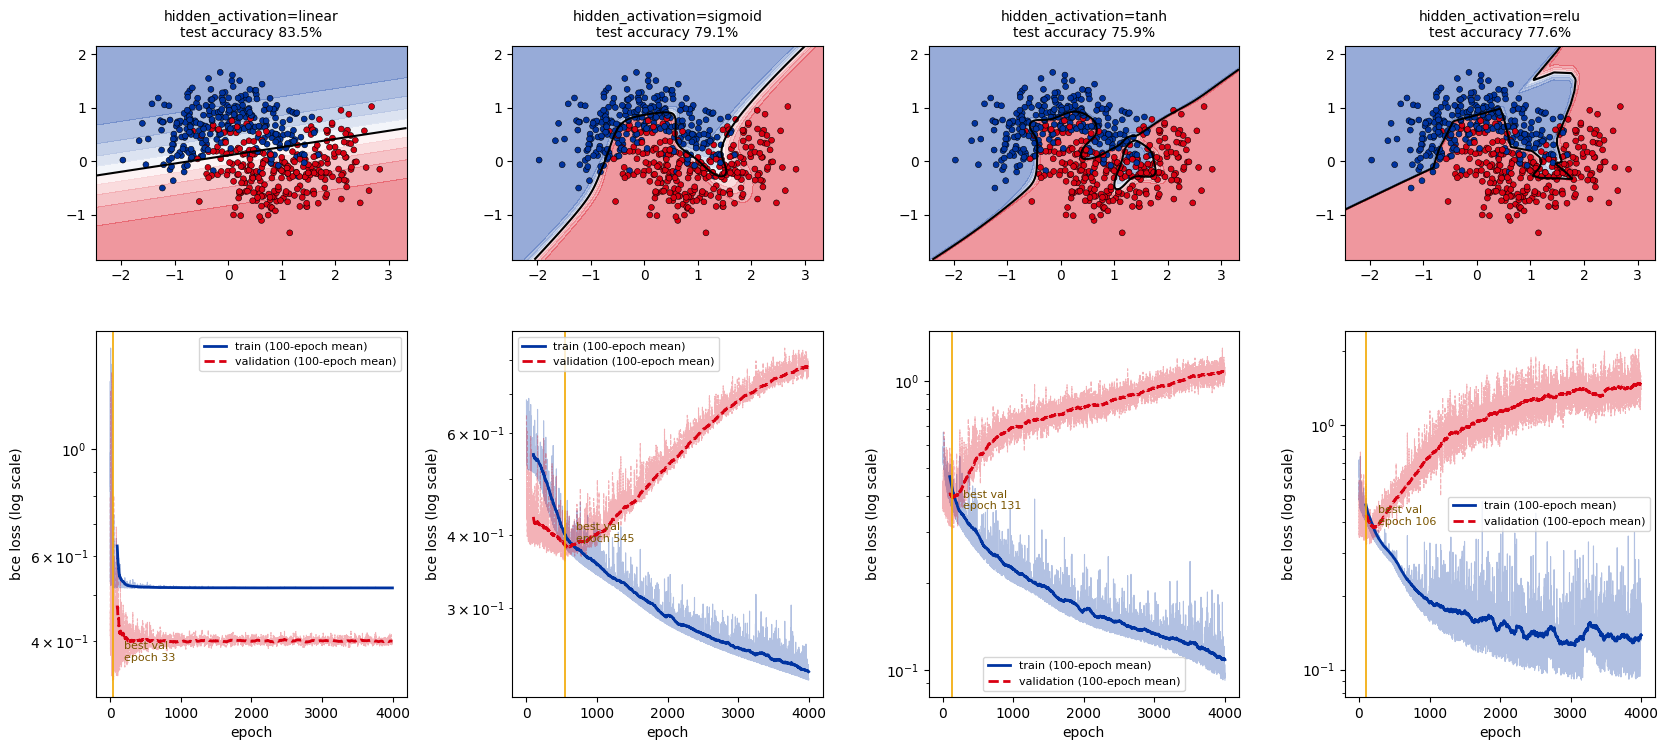

In [21]:
# ~1.5 min: four 4000-epoch runs
compare([{"hidden_activation": name} for name in ["linear", "sigmoid", "tanh", "relu"]])

**Read this one carefully, because the winner is a trap.** `linear` gets the *best test accuracy*
of the four - and it is the worst model. Without a nonlinearity the two layers collapse into one
linear map, so it is just logistic regression: it draws a straight line, it cannot memorize 60
noisy points, and on this particular dataset a straight line is close to the truth.

That is not "linear is better". It is **underfitting that happens to land near the right answer**,
and you can tell the difference by looking at the training loss: `linear` cannot get its training
loss down, the others drive it toward zero. The real networks (`tanh`, `relu`) have the capacity to
do much better *and* the capacity to memorize noise; the whole job of section 7 is to keep the first
without the second.

`sigmoid` is also the slowest to move, for the reason lecture [42] gives: its derivative never
exceeds 0.25, so every gradient that passes through it shrinks.

### Why sigmoid output pairs with cross-entropy

Multiply the two derivatives, with $A = \sigma(Z)$:

$$
\underbrace{\frac{A - Y}{A(1 - A)\,N}}_{\text{bce}'} \cdot \underbrace{A(1 - A)}_{\sigma'}
= \frac{A - Y}{N}
$$

The $A(1 - A)$ cancels and the gradient is just the error. With MSE it stays, and
$A(1 - A) \approx 0$ whenever the sigmoid saturates - **even when the prediction is confidently
wrong**, which is exactly when the network most needs to learn. The next cell checks that the
general chain rule in `backward` and the textbook shortcut `(A - Y) / N` agree.

In [22]:
cfg = {**CONFIG, "output_activation": "sigmoid", "loss": "bce"}
params, state = initialize(2, cfg["hidden_size"], 1, cfg)
A2, cache = forward(X_train, params, state, cfg, training=False)

chain_rule = bce_derivative(Y_train, A2) * sigmoid_derivative(cache["Z2"])
shortcut = (A2 - Y_train) / Y_train.size
print(f"max |chain rule - shortcut| = {np.abs(chain_rule - shortcut).max():.1e}")

max |chain rule - shortcut| = 1.7e-18


## 9. The same network in PyTorch

Everything above in about fifteen lines. This is the translation table: on the left what we wrote by
hand, on the right what the framework calls it.

| ours | PyTorch |
|---|---|
| `params` dict, `initialize()` | `nn.Module` holds parameters; layers initialize themselves |
| `X @ W1 + b1` | `nn.Linear(2, 64)` |
| the BatchNorm block, `state` | `nn.BatchNorm1d(64)` (running stats live in its *buffers*) |
| the dropout mask | `nn.Dropout(0.3)` |
| `training=True/False` | `model.train()` / `model.eval()` |
| `backward()` - written by hand | `loss.backward()` - autograd builds it from the forward pass |
| `update_params()` | `optimizer.step()`, after `optimizer.zero_grad()` |
| `forward(..., training=False)` | `with torch.no_grad():` |

Two differences that are not cosmetic:

- **`BCEWithLogitsLoss` replaces sigmoid + bce.** It is the same cancellation we derived in section
  8, done inside the loss for numerical safety, so the model outputs raw **logits** and the decision
  threshold is `logit > 0` rather than `p > 0.5`.
- **`bias=False` on the first Linear**, for the reason section 6 measured: BatchNorm removes it.

In [ ]:
# ~4 min: 4000 epochs in PyTorch, the slowest cell in the notebook
import torch
import torch.nn as nn

torch.manual_seed(SEED)

model = nn.Sequential(
    nn.Linear(2, 64, bias=False),   # BatchNorm's beta is the bias; b1 would be dead weight
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 1),               # outputs a logit, not a probability
)
loss_fn = nn.BCEWithLogitsLoss()    # = sigmoid + bce, fused for numerical stability
optimizer = torch.optim.SGD(model.parameters(), lr=CONFIG["learning_rate"])

Xtr = torch.tensor(X_train, dtype=torch.float32)
Ytr = torch.tensor(Y_train, dtype=torch.float32)
Xte = torch.tensor(X_test, dtype=torch.float32)
Yte = torch.tensor(Y_test, dtype=torch.float32)

for epoch in range(CONFIG["epochs"]):
    model.train()                                   # dropout on, BatchNorm uses batch stats
    order = torch.randperm(len(Xtr))
    for start in range(0, len(Xtr), CONFIG["batch_size"]):
        batch = order[start:start + CONFIG["batch_size"]]
        optimizer.zero_grad()                       # gradients accumulate otherwise
        loss = loss_fn(model(Xtr[batch]), Ytr[batch])
        loss.backward()                             # autograd fills every .grad
        optimizer.step()                            # params -= lr * grad

model.eval()                                        # dropout off, BatchNorm uses running stats
with torch.no_grad():
    train_acc = ((model(Xtr) > 0).float() == Ytr).float().mean()
    test_acc = ((model(Xte) > 0).float() == Yte).float().mean()
    val_loss = loss_fn(model(Xte), Yte)

print(f"PyTorch  train acc {train_acc:.1%}  test acc {test_acc:.1%}  val loss {val_loss:.3f}")
print(f"parameters: {sum(p.numel() for p in model.parameters())}")
print("learned    :", [name for name, _ in model.named_parameters()])
print("buffers    :", [name for name, _ in model.named_buffers()])



PyTorch  train acc 86.7%  test acc 84.8%  val loss 0.340
parameters: 321
learned    : ['0.weight', '1.weight', '1.bias', '4.weight', '4.bias']
buffers    : ['1.running_mean', '1.running_var', '1.num_batches_tracked']


Compare that test accuracy and validation loss with the `batchnorm=True, dropout=0.3` column in
section 7. Same architecture, same optimizer, same hyperparameters, two independent
implementations - they land in the same place, which is the strongest evidence that the numpy
backward pass above is right.

Look at the last two printed lines. `named_parameters()` lists what gradient descent updates -
including BatchNorm's `weight` and `bias`, which are our `gamma` and `beta`. `named_buffers()` lists
`running_mean` and `running_var`: saved with the model, restored with the model, but never touched
by the optimizer. That is precisely our `state` dictionary, and the reason a framework needs the
distinction at all.